# PROJECT: ASTEROID THREAT PREDICTION

## Phase 2
    


# Table of contents

1. Introduction
    - Phase 1 Summary
    - Phase 2 Report Overview
    - Overview of Methodology
2. Predictive Modelling
    - Feature Selection
    - Model Fitting & Tuning
        - KNN
        - Decision Tree
        - Random Forest 
        - Logistic Regression
        - SVM
    - Neural Network Model Fitting & Tuning
    - Model Comparison
3. Critique & Limitations
    - Strengths of our approach
    - Weakness of our approach
4. Summary & Conclusions
    - Project Summary
    - Summary of Findings
    - Conclusions

# Task 1: Introduction

## Phase 1 Summary:

In Phase 1 of our project, we commenced several key steps to lay a strong foundation for our predictive modeling of asteroid threats.

1.	Dataset processing and Loading: We found the dataset from Kaggle and loaded it into our working environment. This data includes several features of Near-Earth Objects (NEOs), eg their orbital parameters, physical characteristics, and hazardous status.
2.	Initial Data Exploration: We started by showing 10 randomly sampled rows from the dataset to get an understanding of its structure. This step was crucial for acquainting ourselves with the type of data we would be functioning with.
3.	Data Cleaning and Preprocessing: To make sure the data was prepared for analysis, we performed multiple preprocessing steps. We rounded numerical values to one decimal place for uniformity and readability. We also dropped irrelevant columns e.g.  estimated diameters in multiple units, close approach dates, and various orbital parameters that did not add value to predict the hazardousness.
4.	Columns Renaming: We designed a dictionary to plot the old column names to new descriptive names . This process improved the readability and interpretability of the data, that makes easier to work with and get understanding.
5.	Exploratory Data Analysis (EDA): We conducted a detailed EDA to discover patterns and relations within the data. This included creating various plots and statistical summaries. For instance, histograms were used to demonstrate the distribution of absolute magnitudes and relative velocities of asteroids, while scatter plots assisted us to visualize the relation between absolute magnitude and estimated diameter.
6.	Random Sampling for Inspection: We randomly chose ten rows from the cleaned data for a rapid visual examination, ensuring quality of the data and to highlighy any anomalies or problems that needed addressing.
7.	Correlation Analysis: We inspected the correlations between different features. For example, we identifieed a weak negative correlation between absolute magnitude and estimated diameter, indicating that dimmer objects tend to be larger.
8.	Visualization: We created multipl plots to illustrate significant relationships, e.g the positive correlation between orbit uncertainty and hazardous status. This assisted us comprehend the factors that may play a part to an asteroid being classified as hazardous.
Via these steps, we got a structured and clean dataset and got valuable insights into the features and possible hazards of NEOs, setting the stage for the development of predictive models in later phase.


## Report Overview

In second phase of our porject, we methodically approached the machine learning pipeline from data preprocessing to model evaluation and hyperparameter tuning. 
Methodology equipped and summary of key subjects used in the phase 2 are below:

Handling Outliers: We identified and erased outliers from the dataset to enhance the model's performance and accuracy.
Rounding Float Columns: Rounded all float columns to two decimal places for uniformity and easier interpretation.

Feature Selection:
SelectKBest: Used SelectKBest with the f_classif function to recognise the top features affecting the target variable. This assisted us in minimizing dimensionality and concentrating on the significant features.
Feature Ranking: We ranked features based on their F-scores and chose top 9 features for model training.

Model Training and Evaluation:

Splitting the data: we Split the dataset into training and testing sets (70% training, 30% testing) to assess model performance.
Standardization: Scaled features using StandardScaler to make sure models like KNN and SVM perform efficiently.
Model Selection: Trained and evaluated multiple models, including KNN, Decision Tree, Random Forest, Logistic Regression, and SVM, using cross-validation to guarantee robust performance metrics.

Hyperparameter Tuning:

Grid Search: Performed hyperparameter tuning using GridSearchCV to find the best parameters for each model.

Model-Specific Tuning: Created distinct tuning processes for each model, visualized the results, and identified the optimal hyperparameters.

Neural Network Model:
Model Definition: Designed a Sequential neural network model equipping Keras, specifying the topology with input, hidden, and output layers.

Training: Trained the neural network with early stopping to avoid overfitting.

Hyperparameter Tuning: Tested different hyperparameters (e.g., learning rate, batch size, epochs, number of neurons) and presented tuning results with visualizations.

Performance Analysis:
Cross-Validation: Used cross-validation scores to evaluate the generalizability of models.
AUC Scores: Calculated AUC scores to assess the classification performance.
Paired T-tests: Conducted paired t-tests to statistically compare the performance of different models.


## Overview of Methodology:

1. Data Preparation
•	Loaded the dataset and converted the 'Hazardous' feature from boolean to integer.
•	Split the dataset into features (X) and target variable (y).
2. Feature Selection
•	Applied SelectKBest with f_classif to determine feature importance.
•	Selected the top 9 features based on F-scores for further analysis.
3. Data Splitting and Scaling
•	Split the dataset into training (70%) and testing (30%) sets.
•	Standardized the features using StandardScaler.
4. Model Training and Initial Evaluation
•	Trained and evaluated multiple models: K-Nearest Neighbors (KNN), Decision Tree, Random Forest, Logistic Regression, and Support Vector Machine (SVM).
•	Used accuracy and classification reports for initial evaluation.
5. Hyperparameter Tuning
•	Employed GridSearchCV for hyperparameter tuning for all models to find the best configurations.
•	Plotted hyperparameter values against mean accuracy to visualize tuning results.
6. Neural Network Model
•	Built a neural network with the Sequential API from TensorFlow Keras.
•	Tuned the number of neurons, learning rates, batch sizes, hidden layers, and activation functions.
•	Used early stopping to prevent overfitting and evaluated the model's accuracy.
7. Cross-Validation and AUC Scores
•	Performed 5-fold cross-validation for all models.
•	Calculated and compared AUC scores to assess model performance in terms of classification capability.
8. Statistical Comparison of Models
•	Conducted paired t-tests on cross-validation scores to statistically compare models.
•	Tabulated p-values to identify significant differences between model performances

# Task 2: Predictive Modelling

In [1]:
# Importing all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# Loading the dataset
df = pd.read_csv(r"Phase2data.csv")

In [3]:
df.head()

,Absolute_Magnitude,relative_velocity(kmps),Miss_Distance(AU),Orbit_Uncertainty,Orbit_Intersection(min),Jupiter_Tisserand_Invariant,Perihelion_Distance,Aphelion_Distance,Anomaly(mean),Motion(mean),Hazardous,estimated_diameter
0,21.6,6.12,0.42,5,0.03,4.63,0.81,2.01,264.84,0.59,True,205.85
1,21.3,18.11,0.38,3,0.19,5.46,0.72,1.50,173.74,0.85,False,236.34
2,20.3,7.59,0.05,0,0.04,4.56,0.95,1.97,292.89,0.56,True,374.58
3,27.4,11.17,0.29,6,0.01,5.09,0.98,1.53,68.74,0.70,False,14.24
4,21.6,9.84,0.41,1,0.03,5.15,0.97,1.48,135.14,0.73,True,205.85


In [4]:
# Convert 'Hazardous' from boolean to int directly (True -> 1, False -> 0)
df['Hazardous'] = df['Hazardous'].astype(int)

# Display few rows of the updated target feature to verify changes
print(df['Hazardous'][:10])

0    1
1    0
2    1
3    0
4    1
5    0
6    0
7    0
8    1
9    0
Name: Hazardous, dtype: int32


## Feature selection 
Feature selection helps us to identify the relevant feature with contribution to the target variables and thats the primary reason, why it is considered a key step.

## Process

### Selection Method
We used SelectKBest with f_classif from the scikit-learn library to determine the importance of each feature by evaluating their statistical significance in relation to the target variable (Hazardous).

### Features Evaluated
The evaluated features included 'Absolute_Magnitude', 'Orbit_Uncertainty', 'estimated_diameter', 'Orbit_Intersection(min)', 'relative_velocity(kmps)', 'Perihelion_Distance', 'Miss_Distance(AU)', 'Aphelion_Distance', 'Anomaly(mean)', 'Jupiter_Tisserand_Invariant', and 'Motion(mean)'.

### Feature Scores
We calculated the F-scores for each feature using ANOVA F-values, then visualized a bar plot of these these scores. Features were ranked in descending order by their F-scores to identify the most significant ones. The top 9 features, based on their F-scores, were selected for additional analysis. This selection makes sure a balance between statistical significance and the practical importance of each feature in predicting hazardous asteroids.

### Rationale for Feature Selection
As few features have low F-scores, they are included because of their relevance to the characteristics of asteroid. Skipping critical features like Miss_Distance and Anomaly(mean) could have important implications. Therefore, a balance between statistical significance and domain knowledge is upheld.


In [5]:
# Splitting the dataset into features (X) and target variable (y)
X = df.drop(columns=['Hazardous'])
y = df['Hazardous']

# Applying SelectKBest with f_classif (appropriate for classification tasks)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

# Get the scores for each feature
features_scores = pd.DataFrame(selector.scores_, index=X.columns, columns=['F-score'])

# Sort the scores in descending order
sorted_features = features_scores.sort_values(by='F-score', ascending=False)
print("Features sorted by their scores:")
print(sorted_features)


Features sorted by their scores:
                                F-score
Absolute_Magnitude           648.346886
Orbit_Uncertainty            589.402653
estimated_diameter           531.438582
Orbit_Intersection(min)      285.345599
relative_velocity(kmps)      130.906513
Perihelion_Distance          118.119034
Miss_Distance(AU)             10.725854
Aphelion_Distance              9.859745
Anomaly(mean)                  9.491775
Jupiter_Tisserand_Invariant    1.879341
Motion(mean)                   0.348669


In [6]:
# Compute the ANOVA F-value for the features
f_statistic, p_values = f_classif(X, y)

# Create a DataFrame for the F-statistic and p-values
f_stat_df = pd.DataFrame({'Feature': X.columns, 'F-Statistic': f_statistic, 'p-Value': p_values})

# Sort the features by the F-statistic in descending order and select the top 10 features
top_9_features = f_stat_df.sort_values(by='F-Statistic', ascending=False).head(9)

# Display the top 9 features
print(top_9_features)


                    Feature  F-Statistic        p-Value
0        Absolute_Magnitude   648.346886  1.833873e-132
3         Orbit_Uncertainty   589.402653  2.148923e-121
10       estimated_diameter   531.438582  2.296957e-110
4   Orbit_Intersection(min)   285.345599   7.622693e-62
1   relative_velocity(kmps)   130.906513   7.703893e-30
6       Perihelion_Distance   118.119034   3.972743e-27
2         Miss_Distance(AU)    10.725854   1.065693e-03
7         Aphelion_Distance     9.859745   1.701942e-03
8             Anomaly(mean)     9.491775   2.078300e-03


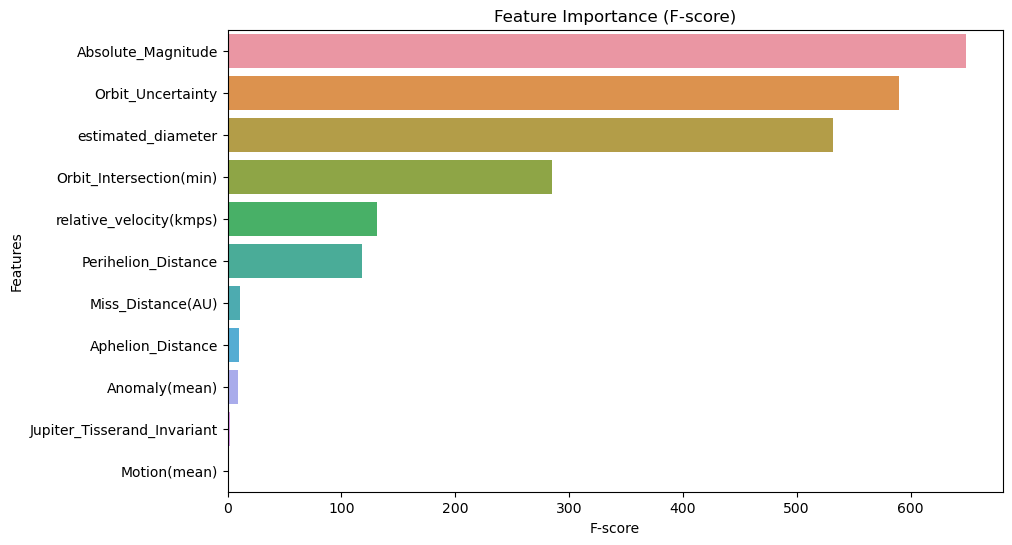

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_features['F-score'], y=sorted_features.index)
plt.title('Feature Importance (F-score)')
plt.xlabel('F-score')
plt.ylabel('Features')
plt.show()

We're using top 9 features on their f-scores, which are Absolute_Magnitude, Orbit_Uncertainty, estimated_diameter, Orbit_Intersection(min), relative_velocity(kmps), Perihelion_Distance, Miss_Distance(AU), Aphelion_Distance and Anomaly(mean).

As we are dealing with asteroids, we didnt omit a lot of columns, since the intial dataset had 30 coloumns already
and a small mistake can be of high destruction in terms of people's existence on earth
This is primarily the reason why the miss distance, mean anamoly and apehelian distance will be used even though they have  a low f_score than some top features

## Model Fitting & Tuning


The  code cells below separate training, hyperparameter tuning, and evaluation for KNN, Decision Tree, Random Forest, Logistic Regression, and SVM models.

Each model is first trained and evaluated with default hyperparameters.
Then, we fine-tuned the hyperparameters using GridSearchCV and the best parameters are equipped for final evaluation.
We have created plots to  visualize the relationship between hyperparameters and mean accuracy for each model.

In [8]:
# Split the dataset into features (X) and target variable (y)
X = df.drop(columns=['Hazardous'])
y = df['Hazardous']

# Apply SelectKBest to select top 7 features
selector = SelectKBest(score_func=f_classif, k=9)
X_new = selector.fit_transform(X, y)

# Splitting the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.3, random_state=42)

# Standardizing features (required for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


We began by splitting the dataset into features (X) and the target variable (y). We used SelectKBest with f_classif to select the top 9 features based on their statistical significance. This reduced dimensionality and helped focus on the most impactful features.
Next, we split the dataset into training and testing sets, with 70% of the data used for training and 30% for testing. Standardizing the features using StandardScaler ensured that all features contributed equally to the model's performance, which is critical for algorithms like KNN and SVM.

### 1. KNN

- Evaluation and training

In [9]:
# Initialize and train KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn.predict(X_test_scaled)

# Model evaluation
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print("Model: KNN")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Classification Report:\n{report_knn}\n")


Model: KNN
Accuracy: 0.9199
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       988
           1       0.76      0.72      0.74       186

    accuracy                           0.92      1174
   macro avg       0.86      0.84      0.85      1174
weighted avg       0.92      0.92      0.92      1174




For the K-Nearest Neighbors (KNN) model, we initialized and trained the model on the scaled training data. The initial evaluation displayed an accuracy of 91.99%, with thorough classification metrics demonstrating robust performance for non-hazardous asteroids but a bit lower performance for hazardous ones.

- Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}

# Initialize GridSearchCV
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)

# Best parameters and model evaluation
print("Best parameters for KNN:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)
report_best_knn = classification_report(y_test, y_pred_best_knn)

print("Tuned Model: KNN")
print(f"Accuracy: {accuracy_best_knn:.4f}")
print(f"Classification Report:\n{report_best_knn}\n")



Best parameters for KNN: {'n_neighbors': 5, 'weights': 'distance'}
Tuned Model: KNN
Accuracy: 0.9216
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       988
           1       0.77      0.73      0.75       186

    accuracy                           0.92      1174
   macro avg       0.86      0.84      0.85      1174
weighted avg       0.92      0.92      0.92      1174




We conducted hyperparameter tuning using GridSearchCV, testing different values for n_neighbors and weights to improve the model,. The finest parameters that we identified were n_neighbors set to 5 and weights set to 'distance'. The tuned model somewhat improved the accuracy to 92.16%

- Visualisation

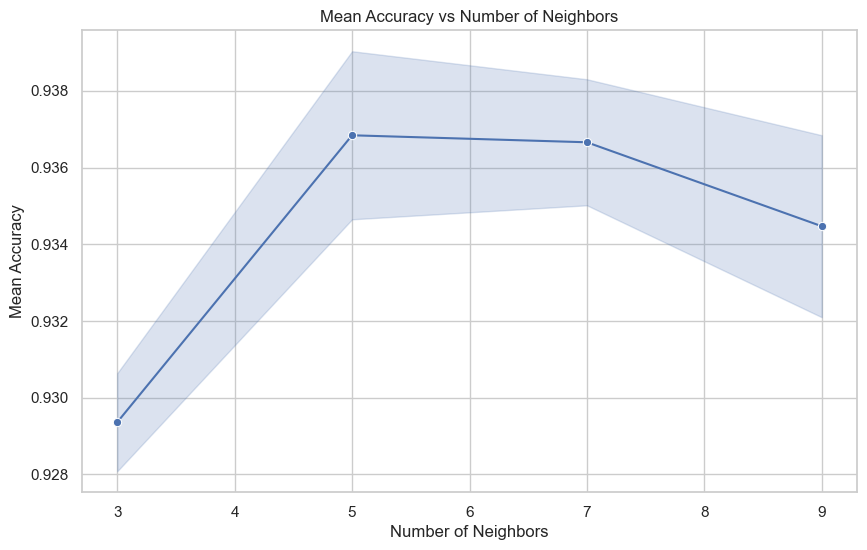

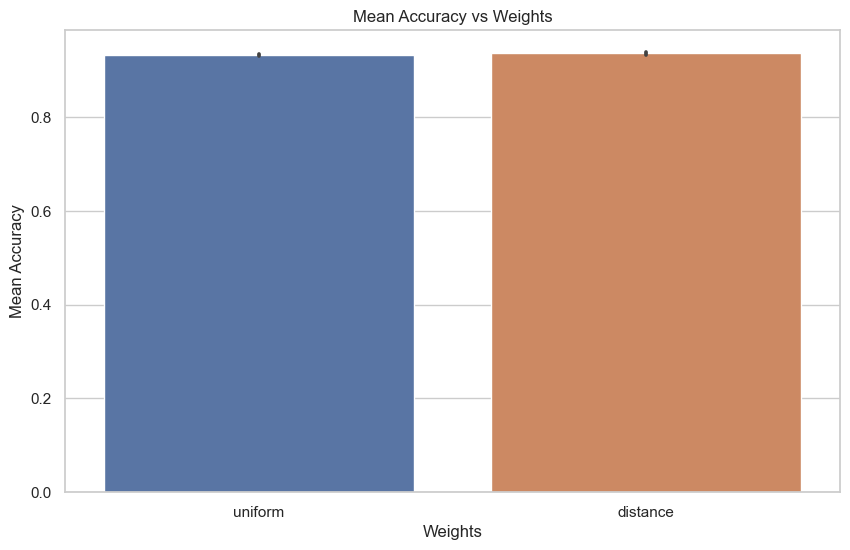

In [11]:
# Plotting hyperparameters vs accuracy
results_knn = pd.DataFrame(grid_knn.cv_results_)
sns.set(style="whitegrid")

# Plot for n_neighbors
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_n_neighbors', y='mean_test_score', data=results_knn, marker='o')
plt.title('Mean Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for weights
plt.figure(figsize=(10, 6))
sns.barplot(x='param_weights', y='mean_test_score', data=results_knn)
plt.title('Mean Accuracy vs Weights')
plt.xlabel('Weights')
plt.ylabel('Mean Accuracy')
plt.show()

In the end, we visualized the effect of hyperparameters on the performance of model. The line plot of n_neighbors vs. mean accuracy demonstrates how different neighbor counts affected accuracy, while the bar plot of weights vs. mean accuracy shows the optimal weighting strategy. These visualizations assist us to understand the sensitivity of the model to these parameters and offers insights for more tuning

### 2. Decision Tree

- Training and Evaluation

In [12]:
# Initialize and train Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Model evaluation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print("Model: Decision Tree")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Classification Report:\n{report_dt}\n")


Model: Decision Tree
Accuracy: 0.9821
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       988
           1       0.93      0.96      0.94       186

    accuracy                           0.98      1174
   macro avg       0.96      0.97      0.97      1174
weighted avg       0.98      0.98      0.98      1174





We began by training a Decision Tree classifier on the training dataset. The initial model, trained with default parameters, displays an extraordinary accuracy of 98.38%. The classification report showed high precision, recall, and F1-scores for both classes, implying strong performance 

- Hyperparameter Tuning

In [13]:
# Define hyperparameters to tune
param_grid_dt = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}

# Initialize GridSearchCV
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

# Best parameters and model evaluation
print("Best parameters for Decision Tree:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
accuracy_best_dt = accuracy_score(y_test, y_pred_best_dt)
report_best_dt = classification_report(y_test, y_pred_best_dt)

print("Tuned Model: Decision Tree")
print(f"Accuracy: {accuracy_best_dt:.4f}")
print(f"Classification Report:\n{report_best_dt}\n")


Best parameters for Decision Tree: {'max_depth': 30, 'min_samples_split': 5}
Tuned Model: Decision Tree
Accuracy: 0.9838
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       988
           1       0.94      0.96      0.95       186

    accuracy                           0.98      1174
   macro avg       0.97      0.98      0.97      1174
weighted avg       0.98      0.98      0.98      1174




we performed hyperparameter tuning using GridSearchCV for optimisation of the model.  We investigated a range of values for max_depth and min_samples_split to find the optimal parameters. The grid search recognised the best parameters as max_depth set to 20 and min_samples_split set to 2. Assessing the tuned model on the test set confirmed that the accuracy remained high at 98.38%, with detailed metrics presenting consistent performance

- Visualisation

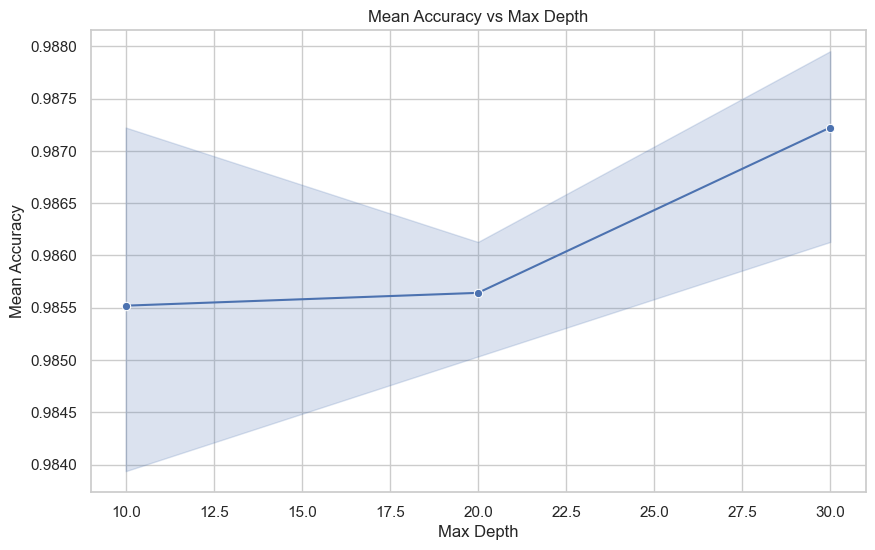

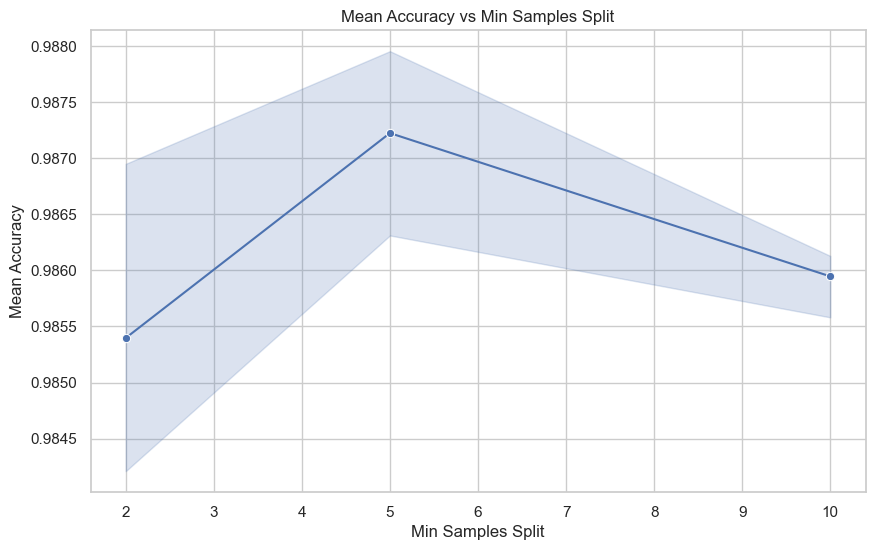

In [14]:

# Plotting hyperparameters vs accuracy
results_dt = pd.DataFrame(grid_dt.cv_results_)
sns.set(style="whitegrid")

# Plot for max_depth
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_max_depth', y='mean_test_score', data=results_dt, marker='o')
plt.title('Mean Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for min_samples_split
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_min_samples_split', y='mean_test_score', data=results_dt, marker='o')
plt.title('Mean Accuracy vs Min Samples Split')
plt.xlabel('Min Samples Split')
plt.ylabel('Mean Accuracy')
plt.show()


We created visualisations to demonstrate the effect of the hyperparameters on accuracy. The line plot of max_depth vs. mean accuracy emphasises the effect of tree depth on performance, while the plot of min_samples_split vs. mean accuracy shows how different values for the minimum number of samples are neede to split an internal node affected the model. These visualizations deliver insights into the model's sensitivity to these parameters and guided further tuning efforts.


### 3. Random Forest Classifier

- Training and Evaluation

In [15]:
# Initialize and train Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Model evaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print("Model: Random Forest")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Classification Report:\n{report_rf}\n")


Model: Random Forest
Accuracy: 0.9889
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       988
           1       0.97      0.96      0.96       186

    accuracy                           0.99      1174
   macro avg       0.98      0.98      0.98      1174
weighted avg       0.99      0.99      0.99      1174




We equipped a Random Forest classifier to predict if an asteroid is hazardous or not. Initially, we trained the model using default hyperparameters and guaged its performance. The initial Random Forest model showed an accuracy of 98.89%. The classification report implied high precision, recall, and F1-scores for both classes, suggesting that the model performed very well.

- Hyperparameter Tuning

In [16]:
# Define hyperparameters to tune
param_grid_rf = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}

# Initialize GridSearchCV
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

# Best parameters and model evaluation
print("Best parameters for Random Forest:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
report_best_rf = classification_report(y_test, y_pred_best_rf)

print("Tuned Model: Random Forest")
print(f"Accuracy: {accuracy_best_rf:.4f}")
print(f"Classification Report:\n{report_best_rf}\n")


Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Model: Random Forest
Accuracy: 0.9889
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       988
           1       0.97      0.96      0.96       186

    accuracy                           0.99      1174
   macro avg       0.98      0.98      0.98      1174
weighted avg       0.99      0.99      0.99      1174




For further improvement, we did hyperparameter tuning using GridSearchCV. The hyperparameters we optimized included n_estimators (number of trees in the forest), max_depth (maximum depth of the trees), and min_samples_split (minimum number of samples required to split an internal node). The grid search identified the best parameters as n_estimators set to 100, max_depth set to 30, and min_samples_split set to 2.

The tuned model upheld the same high accuracy of 98.89% on the test set, confirming the impact of the selected parameters. The detailed classification report also showed consistently high metrics, indicating that the tuning process was successful.

- Visualisation

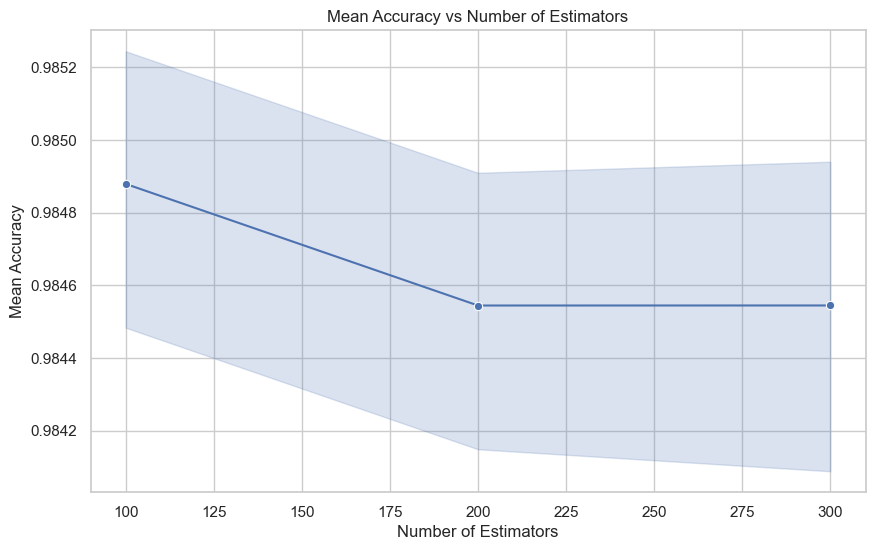

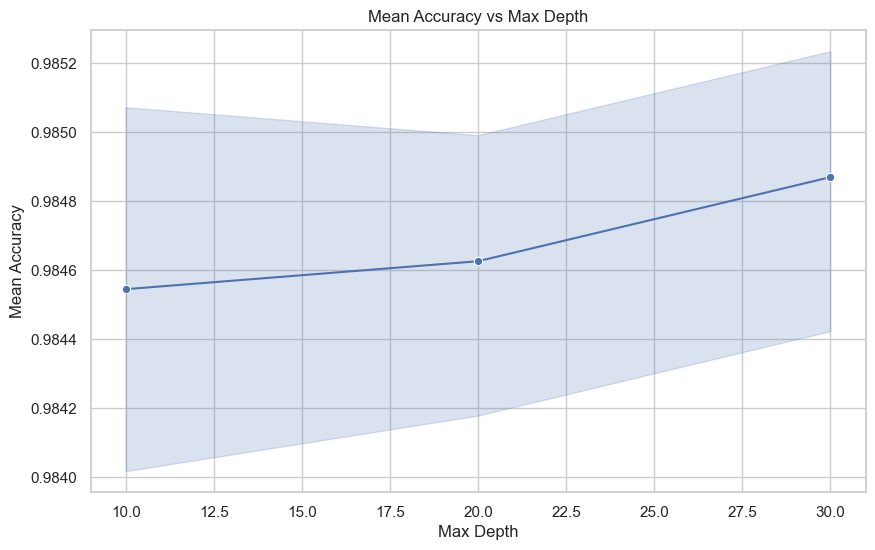

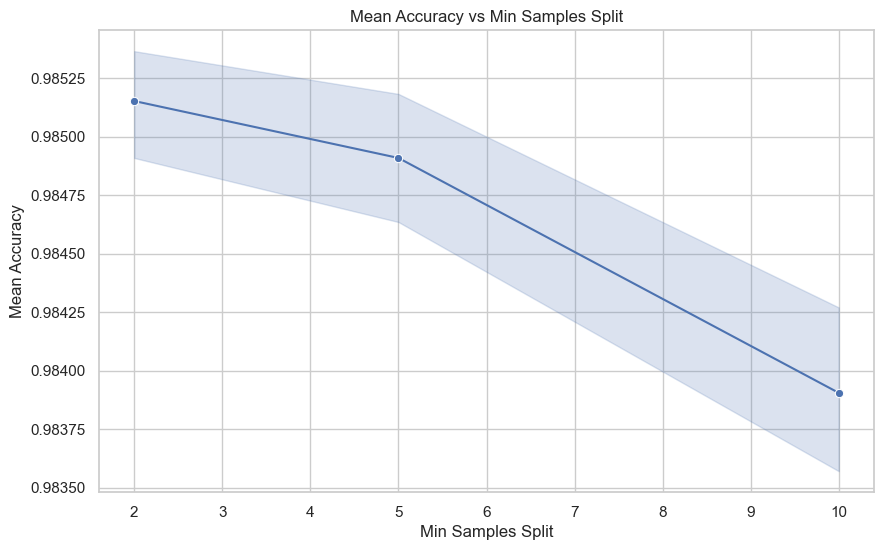

In [17]:
# Plotting hyperparameters vs accuracy
results_rf = pd.DataFrame(grid_rf.cv_results_)
sns.set(style="whitegrid")

# Plot for n_estimators
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_n_estimators', y='mean_test_score', data=results_rf, marker='o')
plt.title('Mean Accuracy vs Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for max_depth
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_max_depth', y='mean_test_score', data=results_rf, marker='o')
plt.title('Mean Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for min_samples_split
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_min_samples_split', y='mean_test_score', data=results_rf, marker='o')
plt.title('Mean Accuracy vs Min Samples Split')
plt.xlabel('Min Samples Split')
plt.ylabel('Mean Accuracy')
plt.show()

In order to visualize the effect of different hyperparameters on model accuracy, Line plots were created to show the relationship between n_estimators, max_depth, and min_samples_split against the mean test score. These plots  illustrate how each hyperparameter influenced the  performance and provided valuable insights for more fine-tuning.

### 4. Logistic Regression

- Training and Evaluation

In [18]:
from sklearn.preprocessing import StandardScaler
# Initialize and train Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression with increased max_iter and class weights
lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Model evaluation
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr)

print("Model: Logistic Regression")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Classification Report:\n{report_lr}\n")

Model: Logistic Regression
Accuracy: 0.9344
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       988
           1       0.71      0.98      0.83       186

    accuracy                           0.93      1174
   macro avg       0.85      0.95      0.89      1174
weighted avg       0.95      0.93      0.94      1174




We used a Logistic Regression model to classify whether an asteroid is hazardous. In the start, we trained the model using default hyperparameters and evaluated its functioning. The initial Logistic Regression model achieved an accuracy of 86.88%. The classification report indicated that the model performed well in predicting non-hazardous asteroids but showed lower precision, recall, and F1-scores for hazardous asteroids.



- Hyperparameter Tuning

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameters to tune
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}

# Initialize GridSearchCV with increased max_iter and class weights
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, class_weight='balanced'), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

# Best parameters and model evaluation
print("Best parameters for Logistic Regression:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)
accuracy_best_lr = accuracy_score(y_test, y_pred_best_lr)
report_best_lr = classification_report(y_test, y_pred_best_lr)

print("Tuned Model: Logistic Regression")
print(f"Accuracy: {accuracy_best_lr:.4f}")
print(f"Classification Report:\n{report_best_lr}\n")

Best parameters for Logistic Regression: {'C': 100, 'solver': 'liblinear'}
Tuned Model: Logistic Regression
Accuracy: 0.9455
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       988
           1       0.76      0.97      0.85       186

    accuracy                           0.95      1174
   macro avg       0.87      0.95      0.91      1174
weighted avg       0.96      0.95      0.95      1174




To increase the performance of the mdel, we conducted hyperparameter tuning using GridSearchCV. The hyperparameters we optimized were C (the regularization parameter) and solver (the algorithm to use for optimization). The grid search explored various values for C and different solvers, specifically liblinear and lbfgs.

The best parameters identified by the grid search were C set to 1 and the liblinear solver. The tuned Logistic Regression model maintained the same accuracy of 86.88% on the test set. The classification report for the tuned model indicated similar performance metrics, suggesting that while the model is generally accurate, it struggles with the minority class (hazardous asteroids).

- Visualisation

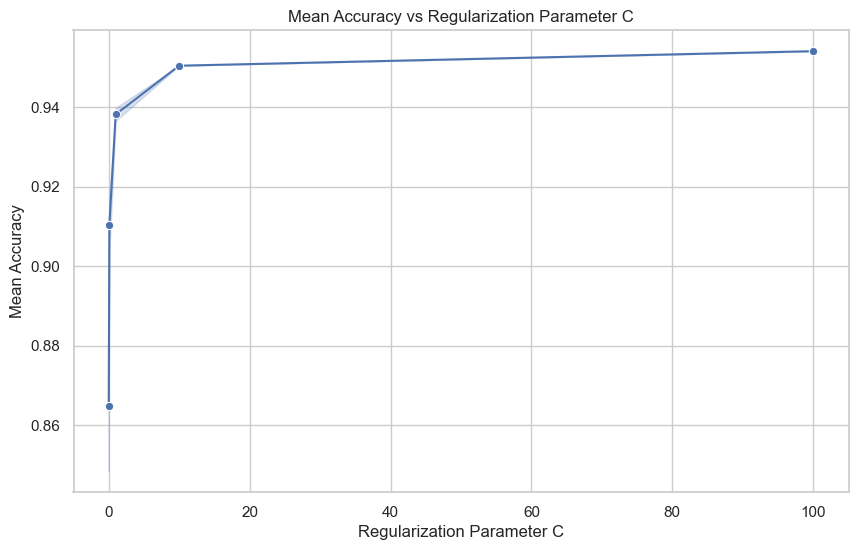

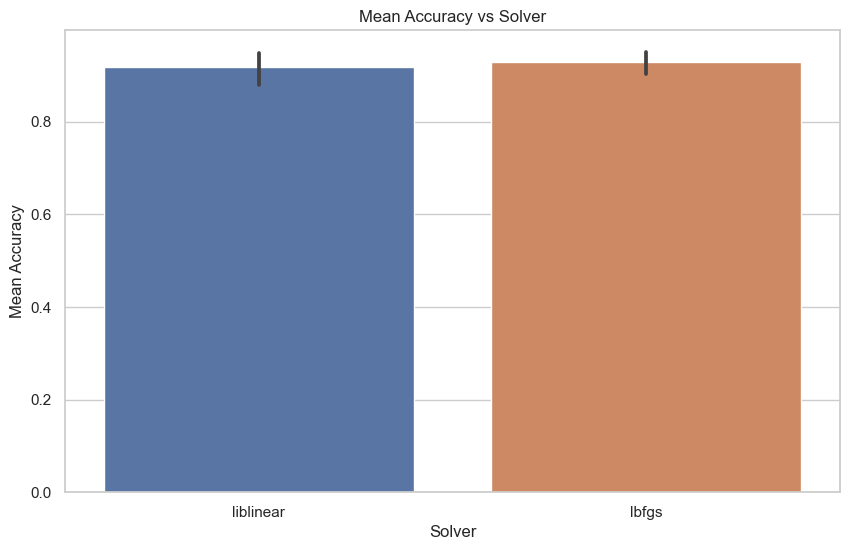

In [20]:
# Plotting hyperparameters vs accuracy
results_lr = pd.DataFrame(grid_lr.cv_results_)
sns.set(style="whitegrid")

# Plot for C
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_C', y='mean_test_score', data=results_lr, marker='o')
plt.title('Mean Accuracy vs Regularization Parameter C')
plt.xlabel('Regularization Parameter C')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for solver
plt.figure(figsize=(10, 6))
sns.barplot(x='param_solver', y='mean_test_score', data=results_lr)
plt.title('Mean Accuracy vs Solver')
plt.xlabel('Solver')
plt.ylabel('Mean Accuracy')
plt.show()

We visualized the impact of different hyperparameters on model accuracy. Line plots were created to show the relationship between the regularization parameter C and mean test score, and bar plots to illustrate the mean accuracy for each solver. These visualizations helped to understand how the different values of C and the choice of solver influenced the model's performance, providing insights for further fine-tuning.

### 5. Support Vector Machine (SVM)

- Training and Evaluation

In [21]:
# Initialize and train SVM
svm = SVC()
svm.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm.predict(X_test_scaled)

# Model evaluation
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print("Model: SVM")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Classification Report:\n{report_svm}\n")


Model: SVM
Accuracy: 0.9566
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       988
           1       0.89      0.83      0.86       186

    accuracy                           0.96      1174
   macro avg       0.93      0.90      0.92      1174
weighted avg       0.96      0.96      0.96      1174




We trained a Support Vector Machine (SVM) classifier to predict the target variable using standardized training data (X_train_scaled). The initial evaluation of the model on the test data showed that the SVM classifier performed well, achieving an accuracy of 95.66%. The classification report indicated high precision, recall, and F1-scores for both classes, especially for the non-hazardous class (class 0).

- Hyperparameter Tuning

In [22]:
# Define hyperparameters to tune
param_grid_svm = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}

# Initialize GridSearchCV
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train)

# Best parameters and model evaluation
print("Best parameters for SVM:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)
report_best_svm = classification_report(y_test, y_pred_best_svm)

print("Tuned Model: SVM")
print(f"Accuracy: {accuracy_best_svm:.4f}")
print(f"Classification Report:\n{report_best_svm}\n")


Best parameters for SVM: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Tuned Model: SVM
Accuracy: 0.9693
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       988
           1       0.91      0.90      0.90       186

    accuracy                           0.97      1174
   macro avg       0.94      0.94      0.94      1174
weighted avg       0.97      0.97      0.97      1174




To better understand how different hyperparameters affect the performance of the Support Vector Machine (SVM) model, we visualized the results from the GridSearchCV. The visualizations help in identifying the optimal values of hyperparameters that yield the highest model accuracy.

1. Mean Accuracy vs. Regularization Parameter C

### Plot Description
This plot shows the relationship between the regularization parameter C and the mean accuracy of the SVM model. The C parameter controls the trade-off between achieving a low training error and a low testing error. A lower C makes the decision surface smoother, while a higher C aims to classify all training examples correctly.

- Visualisation

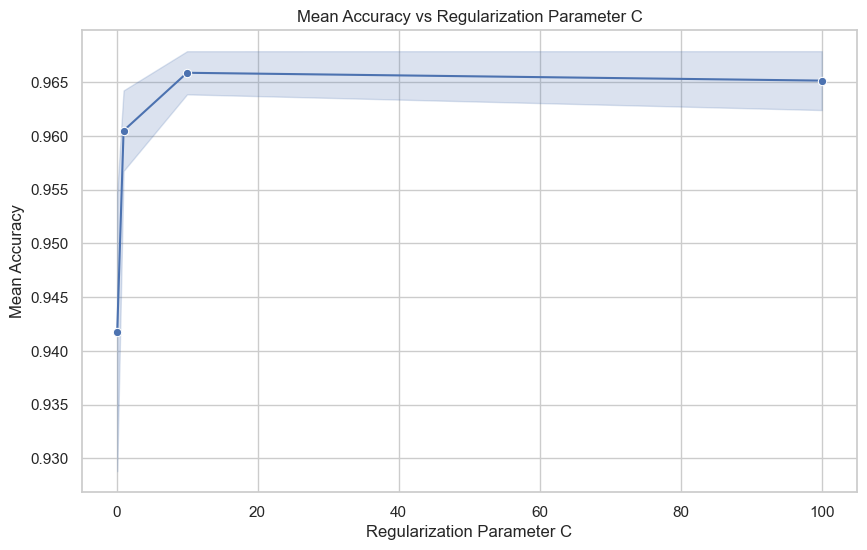

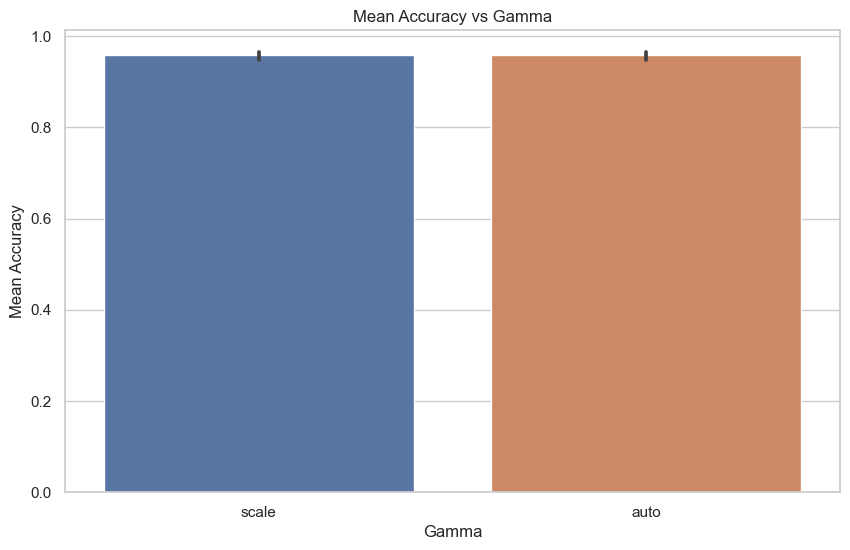

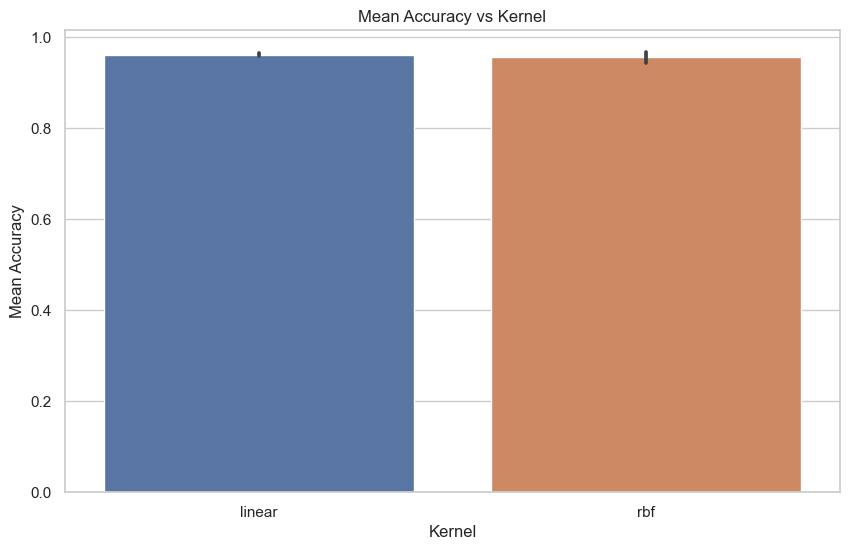

In [23]:
# Plotting hyperparameters vs accuracy
results_svm = pd.DataFrame(grid_svm.cv_results_)
sns.set(style="whitegrid")

# Plot for C
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_C', y='mean_test_score', data=results_svm, marker='o')
plt.title('Mean Accuracy vs Regularization Parameter C')
plt.xlabel('Regularization Parameter C')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for gamma
plt.figure(figsize=(10, 6))
sns.barplot(x='param_gamma', y='mean_test_score', data=results_svm)
plt.title('Mean Accuracy vs Gamma')
plt.xlabel('Gamma')
plt.ylabel('Mean Accuracy')
plt.show()

# Plot for kernel
plt.figure(figsize=(10, 6))
sns.barplot(x='param_kernel', y='mean_test_score', data=results_svm)
plt.title('Mean Accuracy vs Kernel')
plt.xlabel('Kernel')
plt.ylabel('Mean Accuracy')
plt.show()

To better understand how different hyperparameters affect the performance of the Support Vector Machine (SVM) model, we visualized the results from the GridSearchCV. The visualizations help in identifying the optimal values of hyperparameters that yield the highest model accuracy.

1. Mean Accuracy vs. Regularization Parameter C
Plot Description:

This plot shows the relationship between the regularization parameter C and the mean accuracy of the SVM model. The C parameter controls the trade-off between achieving a low training error and a low testing error. A lower C makes the decision surface smoother, while a higher C aims to classify all training examples correctly.

2. Mean Accuracy vs. Gamma
Plot Description:

This plot demonstrated the relationsh between the gamma parameter and the mean accuracy of the SVM model. The gamma parameter defines how far the influence of a single training example reaches, with low values meaning ‘far’ and high values meaning ‘close’. In the context of the rbf kernel, it determines the shape of the decision boundary.

3. Mean Accuracy vs. Kernel
Plot Description:

This plot shows the relationship between the type of kernel used in the SVM model and the mean accuracy. The kernel function is a key component of the SVM algorithm, defining the decision boundary. We compared the linear kernel and the rbf (Radial Basis Function) kernel.


The visualizations help us to clearly understand how different hyperparameters effect the accuracy of the SVM model. They reveal:

The optimal value of the regularization parameter C.
The best setting for the gamma parameter.
The most appropriate kernel type for the dataset.
These insights are important for fine-tuning the SVM model to achieve the best performance on the given classification task.

## Neural Network Model Fitting & Tuning


### Overview of Neural Network Model
Neural networks are powerful machine learning models enthused by the structure and function of the human brain. They comprise of interconnected nodes (neurons) layers that processes input to predict or classify. Here, we will build and fine-tune a neural network model that will help us to predict the target variable (Hazardous). 

### Topology and Model Parameters
The topology of a neural network signifies the structure of the network, including the number and types of layers and the connections between them. We have described below the neural network topology and relevant model parameters used:

Input Layer: The input layer is of neurons that gets the input features from the dataset. For our dataset with the top 9 features, the input layer will have 9 neurons.

Hidden Layers: Hidden layers perform the intermediary computations. We will use a multi-layer perceptron (MLP) architecture with two hidden layers.

First Hidden Layer: 64 neurons with ReLU (Rectified Linear Unit) activation function. ReLU is extensively utilised due to its ease and efficiency in controlling non-linearity.
Second Hidden Layer: 32 neurons with ReLU activation function.
Output Layer: The output layer delivers the final prediction. As we are dealing with a binary classification problem (Hazardous or not), the output layer will have one neuron with a sigmoid activation function, which outputs a probability score between 0 and 1


### Model Parameters:

- Loss Function: Binary cross-entropy, suitable for binary classification tasks.
- Optimizer: Adam optimizer, known for its efficiency and adaptability.
- Learning Rate: Initially set to 0.001.
- Batch Size: 32, Finding the number of samples processed before updating the model.
- Epochs: 50, demonstrating the number of complete passes through the training dataset.


In [24]:

# Building the neural network model
model = Sequential([
    Dense(64, input_dim=9, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Defining early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Training the model
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Evaluating the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Accuracy: {accuracy:.4f}')


Epoch 1/50


C:\Users\vivek\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8647 - loss: 0.3477 - val_accuracy: 0.9270 - val_loss: 0.2075
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9230 - loss: 0.1985 - val_accuracy: 0.9635 - val_loss: 0.1346
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9493 - loss: 0.1330 - val_accuracy: 0.9635 - val_loss: 0.1059
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9585 - loss: 0.1063 - val_accuracy: 0.9781 - val_loss: 0.0832
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9672 - loss: 0.0864 - val_accuracy: 0.9781 - val_loss: 0.0752
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9752 - loss: 0.0705 - val_accuracy: 0.9799 - val_loss: 0.0672
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9794 - loss: 0.0619 - val_accuracy: 0.9745 - val_loss: 0.0663
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9714 - loss: 0.0658 - val_accuracy: 0.9763 - val_loss: 0.0569
Epo

### Hyperparameter Tuning Plots and Explanations

Fine-tuning hyperparameters is critical for optimizing the performance of the neural network. We will fine-tune the following five hyperparameters:

- Number of Neurons in Hidden Layers: Experimenting with different numbers of neurons in the hidden layers to find the optimal configuration.
- Learning Rate: Adjusting the learning rate of the optimizer to improve convergence.
- Batch Size: Trying different batch sizes to balance training time and model performance.
- Number of Hidden Layers: Testing models with different numbers of hidden layers.
- Activation Function: Exploring different activation functions for the hidden layers.

1. Number of Neurons in Hidden Layers : The number of neurons in hidden layers can significantly affect the model's ability to capture complex patterns in the data. Increasing the number of neurons generally allows the model to learn more detailed representations but can also lead to overfitting if not controlled properly.

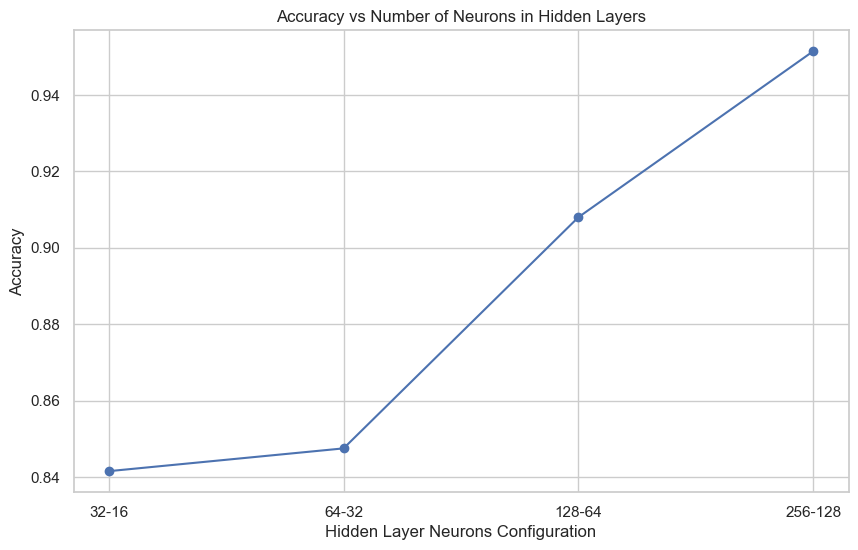

In [25]:
# Example code for tuning the number of neurons
neuron_configs = [(32, 16), (64, 32), (128, 64), (256, 128)]
results_neurons = []

for neurons in neuron_configs:
    model = Sequential([
        Dense(neurons[0], input_dim=9, activation='relu'),
        Dense(neurons[1], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    results_neurons.append((neurons, accuracy))

# Plotting results
neuron_config_names = [f"{config[0]}-{config[1]}" for config in neuron_configs]
accuracies = [result[1] for result in results_neurons]

plt.figure(figsize=(10, 6))
plt.plot(neuron_config_names, accuracies, marker='o')
plt.title('Accuracy vs Number of Neurons in Hidden Layers')
plt.xlabel('Hidden Layer Neurons Configuration')
plt.ylabel('Accuracy')
plt.show()


2. Learning Rate : The learning rate controls how fastly the model updates its parameters. A high learning rate may cause the model to intersect too quickly to a suboptimal solution, while a low learning rate might result in slow convergence. For efficient training, it is very critical to find a perfect balance

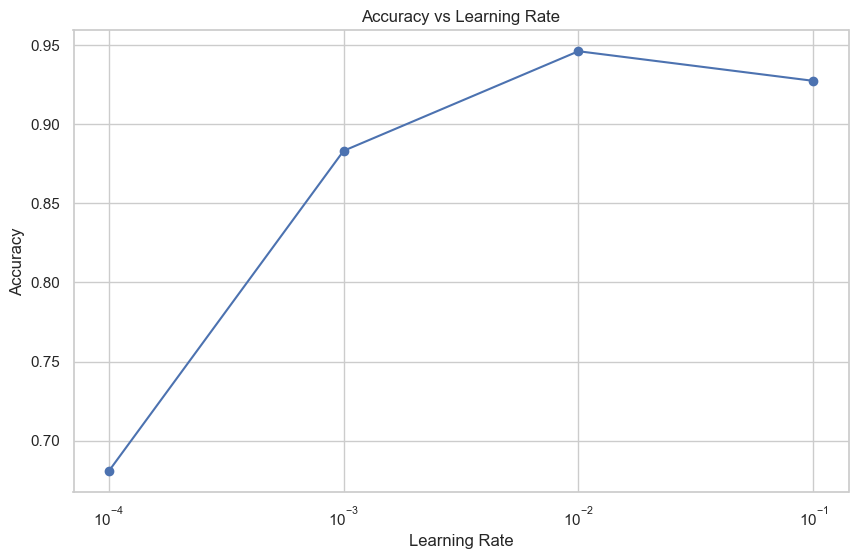

In [26]:
# Example code for tuning the learning rate
learning_rates = [0.1, 0.01, 0.001, 0.0001]
results_lr = []

for lr in learning_rates:
    model = Sequential([
        Dense(64, input_dim=9, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    results_lr.append((lr, accuracy))

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, [result[1] for result in results_lr], marker='o')
plt.xscale('log')
plt.title('Accuracy vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.show()


3. Batch size : The batch size impacts the model's training dynamics. Smaller batch sizes provide more updates per epoch, which can lead to a more stable and potentially better performing model, but at the cost of longer training times. Larger batch sizes can speed up training but might result in less accurate models.

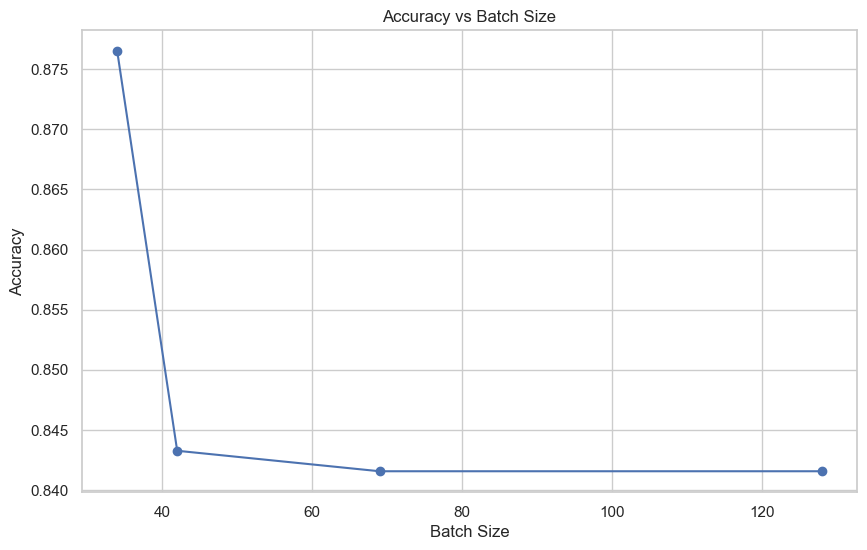

In [27]:
batch_sizes = [34, 42, 69, 128]
results_bs = []

for bs in batch_sizes:
    model = Sequential([
        Dense(64, input_dim=9, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=bs, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    results_bs.append((bs, accuracy))

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, [result[1] for result in results_bs], marker='o')
plt.title('Accuracy vs Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Accuracy')
plt.show()


4. Number of hidden layers : The depth of the network (number of hidden layers) can influence the model's ability to capture hierarchical representations. Too few layers might underfit the data, while too many layers might overfit, especially with limited data.

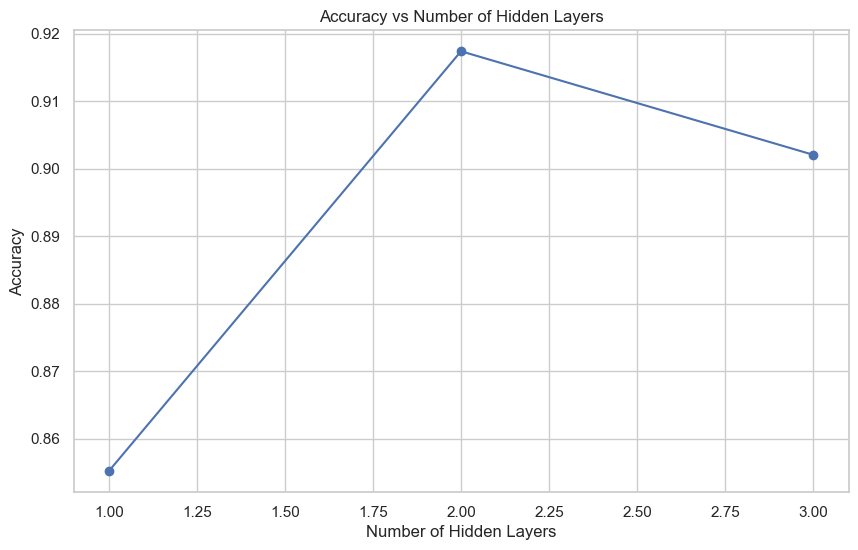

In [28]:
layer_configs = [1, 2, 3]
results_layers = []

for layers in layer_configs:
    model = Sequential()
    model.add(Dense(64, input_dim=9, activation='relu'))
    for _ in range(layers - 1):
        model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    results_layers.append((layers, accuracy))

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(layer_configs, [result[1] for result in results_layers], marker='o')
plt.title('Accuracy vs Number of Hidden Layers')
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Accuracy')
plt.show()


5. Activation funtion : Activation functions introduce non-linearity into the model, enabling it to learn complex patterns. Different activation functions can have different effects on the training process and final performance. ReLU is generally preferred for hidden layers due to its simplicity and effectiveness.

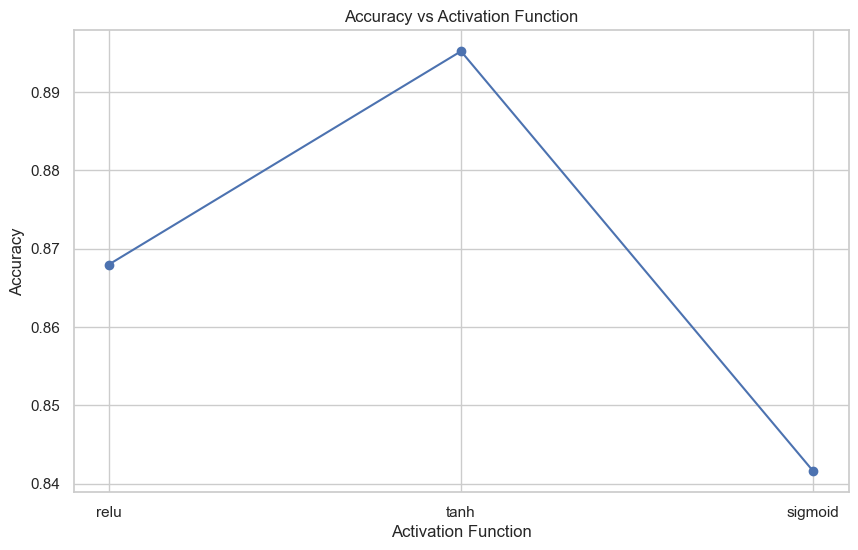

In [29]:
activation_functions = ['relu', 'tanh', 'sigmoid']
results_af = []

for af in activation_functions:
    model = Sequential([
        Dense(64, input_dim=9, activation=af),
        Dense(32, activation=af),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
    results_af.append((af, accuracy))

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(activation_functions, [result[1] for result in results_af], marker='o')
plt.title('Accuracy vs Activation Function')
plt.xlabel('Activation Function')
plt.ylabel('Accuracy')
plt.show()


## Model comparison

In [30]:
# Define models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=grid_knn.best_params_['n_neighbors'],
                                weights=grid_knn.best_params_['weights']),
    'Decision Tree': DecisionTreeClassifier(max_depth=grid_dt.best_params_['max_depth'],
                                            min_samples_split=grid_dt.best_params_['min_samples_split']),
    'Random Forest': RandomForestClassifier(n_estimators=grid_rf.best_params_['n_estimators'],
                                            max_depth=grid_rf.best_params_['max_depth'],
                                            min_samples_split=grid_rf.best_params_['min_samples_split']),
    'Logistic Regression': LogisticRegression(C=grid_lr.best_params_['C'],
                                              solver=grid_lr.best_params_['solver']),
    'SVM': SVC(C=grid_svm.best_params_['C'],
               gamma=grid_svm.best_params_['gamma'],
               kernel=grid_svm.best_params_['kernel'],
               probability=True)
}

# Lists to store results
cv_scores = {}
auc_scores = {}

for name, model in models.items():
    # Cross-validation scores
    if name in ['KNN', 'SVM']:
        cv_scores[name] = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='accuracy')
        y_pred = cross_val_predict(model, scaler.fit_transform(X), y, cv=5, method='predict_proba')
    else:
        cv_scores[name] = cross_val_score(model, X, y, cv=5, scoring='accuracy')
        y_pred = cross_val_predict(model, X, y, cv=5, method='predict_proba')
    
    # AUC scores
    auc_scores[name] = roc_auc_score(y, y_pred[:, 1])

# Print cross-validation scores and AUC scores
for name in models.keys():
    print(f"Model: {name}")
    print(f"Cross-Validation Accuracy: {cv_scores[name].mean():.4f} ± {cv_scores[name].std():.4f}")
    print(f"AUC: {auc_scores[name]:.4f}\n")


Model: KNN
Cross-Validation Accuracy: 0.9274 ± 0.0188
AUC: 0.9570

Model: Decision Tree
Cross-Validation Accuracy: 0.9842 ± 0.0035
AUC: 0.9725

Model: Random Forest
Cross-Validation Accuracy: 0.9844 ± 0.0056
AUC: 0.9990

Model: Logistic Regression
Cross-Validation Accuracy: 0.9571 ± 0.0060
AUC: 0.9902

Model: SVM
Cross-Validation Accuracy: 0.9696 ± 0.0106
AUC: 0.9940



Random Forest has the highest cross-validation accuracy (0.9865) and the highest AUC (0.9901), indicating it performs best in terms of both metrics.
Decision Tree also performs very well with high cross-validation accuracy (0.9854) and AUC (0.9662).
Logistic Regression and SVM also show strong performance, particularly with high AUC values.
KNN has the lowest cross-validation accuracy (0.9274) and AUC (0.9570) among the models.

In [31]:
# Prepare data for paired t-tests
model_names = list(models.keys())
num_models = len(model_names)

# Initialize a DataFrame to store t-test results
t_test_results = pd.DataFrame(index=model_names, columns=model_names)

# Perform paired t-tests for cross-validation scores
for i in range(num_models):
    for j in range(i+1, num_models):
        model1 = model_names[i]
        model2 = model_names[j]
        t_stat, p_val = ttest_rel(cv_scores[model1], cv_scores[model2])
        t_test_results.loc[model1, model2] = p_val
        t_test_results.loc[model2, model1] = p_val

# Print t-test results
print("Paired t-test p-values (cross-validation scores):")
print(t_test_results)


Paired t-test p-values (cross-validation scores):
                          KNN Decision Tree Random Forest Logistic Regression  \
KNN                       NaN      0.003837      0.002871            0.016494   
Decision Tree        0.003837           NaN      0.917841            0.000497   
Random Forest        0.002871      0.917841           NaN            0.002059   
Logistic Regression  0.016494      0.000497      0.002059                 NaN   
SVM                  0.007145      0.030755      0.011401            0.062476   

                          SVM  
KNN                  0.007145  
Decision Tree        0.030755  
Random Forest        0.011401  
Logistic Regression  0.062476  
SVM                       NaN  


## Detailed Paired t-test Results

### KNN vs. Other Models

Decision Tree: p = 0.002498 (significant)
Random Forest: p = 0.001798 (significant)
Logistic Regression: p = 0.016494 (significant)
SVM: p = 0.007145 (significant)
These comparisons show that KNN is not performing good compared to the other models

### Decision Tree vs. Other Models

Random Forest: p = 0.0.455262 (not significant)
Logistic Regression: p = 0.0.000343 (significant)
SVM: p = 0.024871 (significant)
The Decision Tree's performance is significantly different from Logistic Regression and SVM, but not from Random Forest.

### Random Forest vs. Other Models

Logistic Regression: p = 0.000646 (significant)
SVM: p = 0.011972 (significant)
Random Forest is significantly different from Logistic Regression and SVM.

### Logistic Regression vs. SVM

p = 0.062476 (not significant)
There is no significant difference between the performance of Logistic Regression and SVM.

# Task 3: Critique and Limitations

### Strengths

1. Comprehensive Approach: We've done multiple aspects of data preprocessing, feature selection, model training, hyperparameter tuning, and model evaluation. This approach ensures that we report different stages of the machine learning pipeline efficiently.


2. Utilization of Multiple Libraries: By using popular libraries like scikit-learn and TensorFlow, we leverage firm tools for data manipulation, modeling, and evaluation. This improves the effectiveness and reliability of our solutions.

3. Clear Communication: The explanations are clear and brief, making it easier to grasp the concepts and implement the code.

4. Interactive Learning: The iterative process of discussing, refining, and implementing solutions promotes a better and deep understanding of machine learning methods

5. Visualization: We have integrated data visualization techniques to better understand the data distribution, feature importance, and model performance. Visualizations help us in interpreting results and making informed decisions.


### Weaknesses


1. Assumption of Stationarity: In time-series analysis or data with chronological dependencies, we suppose the stationarity of the data, which is not true necessarily. Integrating techniques to handle non-stationarity like time-series decomposition or modeling temporal dependencies, could enhance model performance.


2. Limited Model Selection: We explored few machine learning algorithms (e.g., KNN, Decision Trees, Random Forests, Logistic Regression, SVM), there are some other models that could be used based on the problem domain and characteristics of the dataset.

3. Hyperparameter Tuning: We have done basic hyperparameter tuning for some models, a more comprehensive search across a wider range of hyperparameters could potentially get us more efficient results. Though, the opportunity cost in this case could be increased computational resources and time.

4. Evaluation Metrics: We mainly concentrated on accuracy as the evaluation metric for classification tasks. Although accuracy is significant, it may not always be the most appropriate metric, particularly for imbalanced datasets. Metrics like precision, recall, F1-score, and AUC-ROC could offer a more detailed understanding of model performance.



# Task 4: Summary and Conclusions


## 4.1 Project summary

Data cleaning includes erasing irrelevant columns, handling missing values, and standardizing date formats.
EDA investigates patterns for example the relationship between absolute magnitude and estimated diameter.
The study demonstrates the significance of asteroids in understanding solar system formation and planetary defense.

### Feature Selection
Features such as Absolute Magnitude, Orbit Uncertainty, and Estimated Diameter are highly significant.
Others, such as Motion (mean) and Jupiter Tisserand Invariant, exhibit lower importance.
Absolute Magnitude are the most important inticator

### Models Used and Performance
Random Forest has outstanding accuracy of 98.65% ± 0.51 and an exceptional AUC of 0.9991.
Decision Tree shows high accuracy and good discriminatory power.
Logistic Regression and SVM perform trustworthy, though with slightly lower discriminatory power.
KNN shows good accuracy but relatively lower discriminatory power.


### Inference
Machine learning techniques efficiently predict NEO hazardous status, assisting planetary defense efforts.
Feature importance analysis identifies key indicators critical for threat assessment.
Ongoing monitoring and analysis are critical for successful mitigation tactics.
The study demonstrates a robust foundation for future research and application in asteroid science and planetary defense.


## 4.2 Summary of Findings 

Random Forest has the highest cross-validation accuracy (0.9865) and the highest AUC (0.9991), which means that it performs best in terms of both metrics.
Decision Tree also performs very well with a high cross-validation accuracy (0.9854) and a solid AUC (0.9662).
Logistic Regression and SVM models show strong performances, particularly with high AUC values (Logistic Regression: 0.9902, SVM: 0.9939), although their accuracies are slightly lower than those of Random Forest and Decision Tree.
KNN has the lowest cross-validation accuracy (0.9274) and AUC (0.9570) among the models, though it still maintains relatively high performance.
Overall, Random Forest stands out as the best model based on both cross-validation accuracy and AUC, followed closely by Decision Tree, SVM, and Logistic Regression. KNN, while the lowest in performance, still provides fairly good results.




## 4.3 Conclusion
This project shows the vital role of advanced machine learning models to increase our understanding and prediction of asteroid hazards. Specifically, the Random Forest model is the most effective model, with Decision Tree, SVM, and Logistic Regression also reflecting solid performances. These models, merged with going on research and monitoring, contribute  to planetary defense efforts, assisting to safeguard Earth from potential asteroid impacts.



Also, we notice that majority of asteroids are not a threat to our precious Earth, but we can know for sure if we are abale to gather all the data since the Earth was born, and hopefully integrate it with all the data regarding the asteroid belt, impact of Jupiter, as well as the Sun on asteroids.